In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("adult_income.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df = df.replace("?", np.nan)

df = df.dropna()

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (30162, 15)


In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "str":

        df[col] = encoder.fit_transform(df[col])

print("Encoding completed")

Encoding completed


In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0


In [6]:
X = df.drop("income", axis=1)

y = df["income"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (30162, 14)
y Shape: (30162,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24129, 14)
Testing Data: (6033, 14)


In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [9]:
y_pred_clean = model.predict(X_test)

accuracy_clean = accuracy_score(
    y_test,
    y_pred_clean
)

print("Accuracy Before Noise:", accuracy_clean)

Accuracy Before Noise: 0.8473396320238687


In [10]:
X_test_noisy = X_test.copy()

noise = np.random.normal(
    0,
    0.1,
    X_test_noisy.shape
)

X_test_noisy = X_test_noisy + noise

print("Noise added successfully")

Noise added successfully


In [11]:
y_pred_noisy = model.predict(X_test_noisy)

accuracy_noisy = accuracy_score(
    y_test,
    y_pred_noisy
)

print("Accuracy After Noise:", accuracy_noisy)

Accuracy After Noise: 0.8471738770097795


In [12]:
robustness_score = (
    accuracy_noisy / accuracy_clean
) * 100

performance_drop = (
    accuracy_clean - accuracy_noisy
)

print("Robustness Score:", robustness_score)
print("Performance Drop:", performance_drop)

Robustness Score: 99.98043818466354
Performance Drop: 0.00016575501408921944


In [13]:
robustness_table = pd.DataFrame({

    "Metric": [
        "Accuracy_Before_Noise",
        "Accuracy_After_Noise",
        "Robustness_Score",
        "Performance_Drop"
    ],

    "Value": [
        accuracy_clean,
        accuracy_noisy,
        robustness_score,
        performance_drop
    ]
})

robustness_table

,Metric,Value
0,Accuracy_Before_Noise,0.847340
1,Accuracy_After_Noise,0.847174
2,Robustness_Score,99.980438
3,Performance_Drop,0.000166


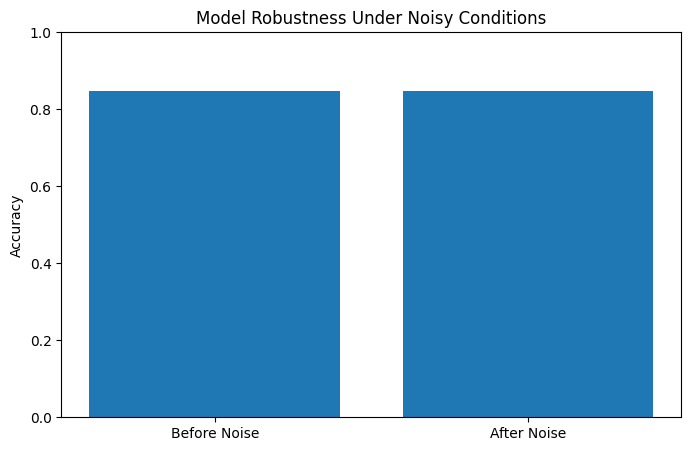

In [14]:
plt.figure(figsize=(8,5))

labels = [
    "Before Noise",
    "After Noise"
]

values = [
    accuracy_clean,
    accuracy_noisy
]

plt.bar(
    labels,
    values
)

plt.ylabel("Accuracy")

plt.title("Model Robustness Under Noisy Conditions")

plt.ylim(0,1)

plt.show()

In [15]:
plt.figure(figsize=(8,5))

labels = [
    "Before Noise",
    "After Noise"
]

values = [
    accuracy_clean,
    accuracy_noisy
]

plt.bar(
    labels,
    values
)

plt.ylabel("Accuracy")

plt.title("Model Robustness Under Noisy Conditions")

plt.ylim(0,1)

plt.savefig(
    "results/RQ4_Robustness.pdf",
    bbox_inches="tight"
)

plt.close()

print("RQ4_Robustness.pdf saved successfully")

RQ4_Robustness.pdf saved successfully


In [16]:
robustness_table.to_csv(
    "results/RQ4_Robustness_Table.csv",
    index=False
)

print("RQ4_Robustness_Table.csv saved successfully")

RQ4_Robustness_Table.csv saved successfully


In [17]:
import os

os.listdir("results")

['RQ2_SHAP_Table.csv',
 'RQ3_Fairness.pdf',
 'RQ2_SHAP.pdf',
 'RQ1_Metrics.csv',
 'RQ4_Robustness_Table.csv',
 'RQ4_Robustness.pdf',
 'RQ1_RadarChart.pdf',
 'RQ3_Fairness_Table.csv']